In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%pip install -U scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Environment ready!
NumPy: 2.0.2
pandas: 2.3.3
scikit-learn: 1.6.1


Environment ready!
NumPy: 2.0.2
pandas: 2.3.3
scikit-learn: 1.6.1
   StudentID  G1  G2  G3      Mjob     Fjob  age address  studytime  failures  \
0          1   6   2   2   teacher  at_home   21   rural          3         1   
1          2  19  11  18    health  teacher   18   rural          1         1   
2          3  14   7  19    health    other   20   urban          1         1   
3          4  10   2   6  services   health   21   urban          3         1   
4          5   7   0  19    health   health   18   rural          4         1   

  schoolsup famsup paid activities nursery higher internet romantic  
0        no    yes  yes        yes     yes    yes       no      yes  
1        no     no   no         no     yes     no       no       no  
2       yes    yes  yes         no      no     no      yes      yes  
3       yes     no  yes         no     yes     no       no       no  
4        no     no  yes         no     yes    yes      yes       no  
     studytime  failures
ag

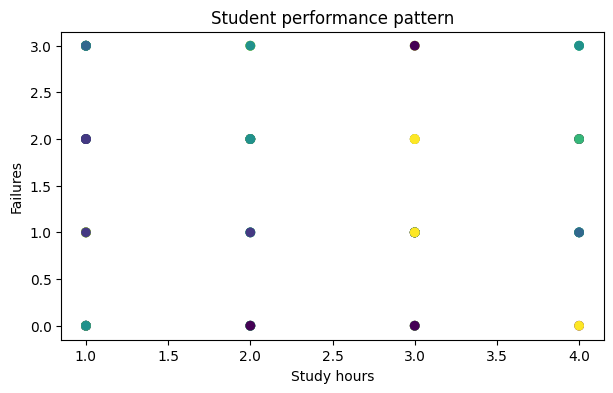

X shape: (100, 2)
y shape: (100,)
Training rows: 80
Testing rows: 20
Model trained!


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Check environment
print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

# Load data
df = pd.read_csv("student_performance.csv")

print(df.head())

# Group data
print(df.groupby("age")[["studytime", "failures"]].mean())

# Plot
plt.figure(figsize=(7, 4))
plt.scatter(df["studytime"], df["failures"], c=df["age"])
plt.xlabel("Study hours")
plt.ylabel("Failures")
plt.title("Student performance pattern")
plt.show()

# Features and target
X = df[["studytime", "failures"]]
y = df["age"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

# Train model
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained!")

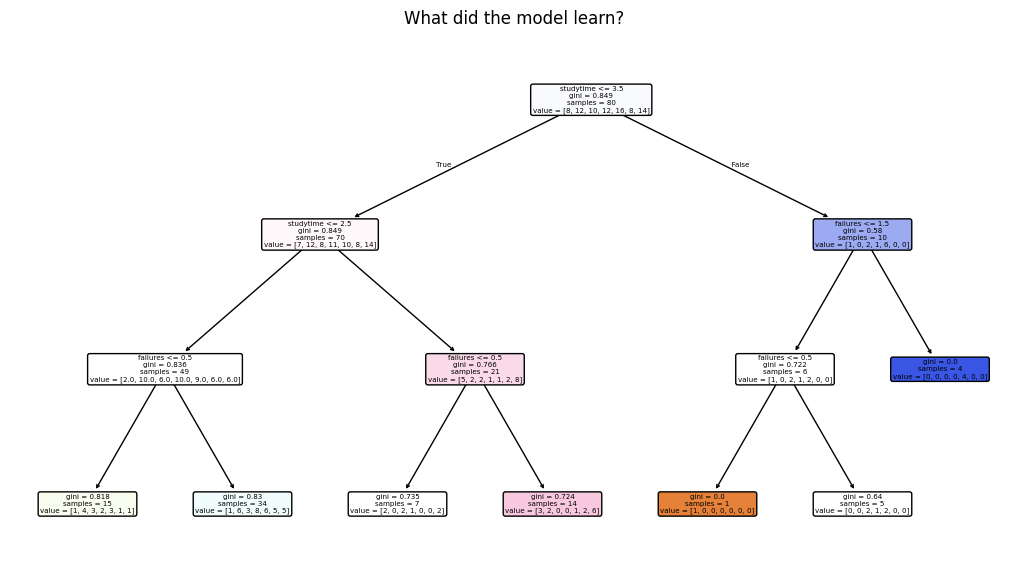

In [18]:
plt.figure(figsize=(13, 7))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.title("What did the model learn?")
plt.show()